In [ ]:
!pip install tensorflow opencv-pyhton matplotlib scikit-learn

In [2]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


Detected ASL dataset labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Loading from folder: 0...
Loading from folder: 1...
Loading from folder: 2...
Loading from folder: 3...
Loading from folder: 4...
Loading from folder: 5...
Loading from folder: 6...
Loading from folder: 7...
Loading from folder: 8...
Loading from folder: 9...
Loading from folder: a...
Loading from folder: b...
Loading from folder: c...
Loading from folder: d...
Loading from folder: e...
Loading from folder: f...
Loading from folder: g...
Loading from folder: h...
Loading from folder: i...
Loading from folder: j...
Loading from folder: k...
Loading from folder: l...
Loading from folder: m...
Loading from folder: n...
Loading from folder: o...
Loading from folder: p...
Loading from folder: q...
Loading from folder: r...
Loading from folder: s...
Loading from folder: t...
Loading fr

C:\Users\rprat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 60)                  │          30,780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,518,780 (9.61 MB)

 Trainable params: 2,517,820 (9.60 MB)

 Non-trainable params: 960 (3.75 KB)

C:\Users\rprat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.3919 - loss: 2.5996 - val_accuracy: 0.4521 - val_loss: 2.4864 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - accuracy: 0.8404 - loss: 0.7109 - val_accuracy: 0.8542 - val_loss: 0.6631 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 366s 974ms/step - accuracy: 0.8949 - loss: 0.5470 - val_accuracy: 0.9363 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 374s 997ms/step - accuracy: 0.9153 - loss: 0.4569 - val_accuracy: 0.7529 - val_loss: 0.9116 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.9225 - loss: 0.4100 - val_accuracy: 0.9600 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.9318 - loss: 0.3738 - val_accuracy: 0.9513 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 371s 988ms/step - accuracy: 0.9402 -

Model saved at 'model/sign_language_model.h5'


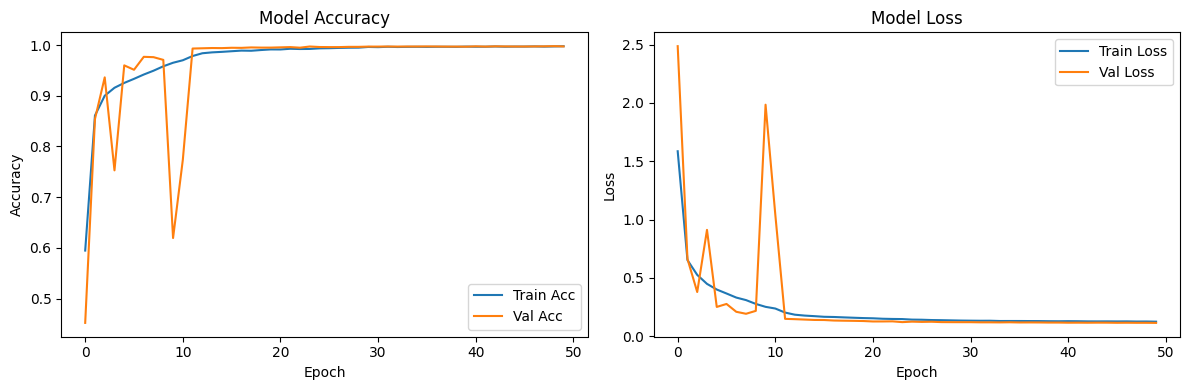

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step


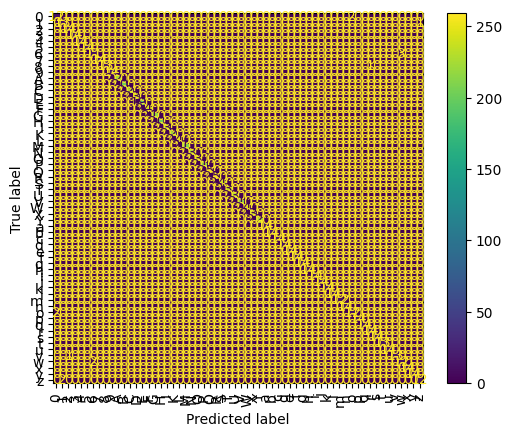

In [4]:
import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# --- CONFIGURATION ---
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 50 # Increased max epochs, controlled by Early Stopping


# DATASET 1: Custom ASL Dataset (folders A-Z)
data_dir = r'D:\SignSpeak\data\asl_dataset'

labels = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print(f"Detected ASL dataset labels: {labels}")

X1, y1 = [], []

for i, label in enumerate(labels):
    folder_path = os.path.join(data_dir, label)
    print(f'Loading from folder: {label}...')
    img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(img_files)

    for img_name in img_files[:1000]:
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # FIX 1: Convert BGR (OpenCV default) to RGB for consistency
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X1.append(img)
        y1.append(label)


# DATASET 2: sign_mnist_train (CSV)
mnist_path = r'D:\SignSpeak\data\sign_mnist_train\sign_mnist_train.csv'
df = pd.read_csv(mnist_path)
print(f"Loaded Sign MNIST dataset with shape: {df.shape}")

# Extract image pixels
X2 = df.iloc[:, 1:].values.astype('uint8').reshape(-1, 28, 28, 1)

# Convert grayscale → RGB and resize safely
X2_rgb = []
for img in X2:
    try:
        img_rgb = np.repeat(img, 3, axis=-1)  # convert to 3 channels
        img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
        X2_rgb.append(img_resized)
    except Exception as e:
        print(" Skipped one image due to error:", e)

X2 = np.array(X2_rgb, dtype=np.float32)

# Load labels
y2 = df['label'].values
label_map = {i: chr(65 + i) for i in range(26)}  # 0 → 'A', etc.
y2 = [label_map[i] for i in y2]

# Combine both datasets
X = np.concatenate((X1, X2), axis=0)
y = np.concatenate((y1, y2), axis=0)

# Normalize all data (0-255 -> 0.0-1.0)
X = np.array(X, dtype=np.float32) / 255.0

# Create final label list and map to integers
unique_labels = sorted(list(set(y)))
print(f" Final label set: {unique_labels}")

label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
y_encoded = [label_to_idx[lbl] for lbl in y]
y = to_categorical(np.array(y_encoded), num_classes=len(unique_labels))

# Save labels for prediction use
os.makedirs('model', exist_ok=True)
with open('model/labels.json', 'w') as f:
    json.dump(unique_labels, f)

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}")

# Image Augmentation
augmentor = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)
augmentor.fit(X_train)


# CNN MODEL (Updated Architecture)
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # Block 4 (Added for better feature extraction)
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'), # Increased density
    Dropout(0.5),
    Dense(len(unique_labels), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
    metrics=['accuracy']
)

model.summary()

# Train the Model (with Callbacks for Stability/Speed)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3, 
    min_lr=0.00001,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, 
    restore_best_weights=True
)

history = model.fit(
    augmentor.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stopping]
)


# Save Model and Plot
model.save('model/sign_language_model.h5')
print("Model saved at 'model/sign_language_model.h5'")

# Plot Accuracy & Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(xticks_rotation=90)
plt.show()
